# PRCP-1021 – Insurance Cost Prediction

# 1. Business Case
# 2. Problem Statement
# 3. Business Objective
# 4. Dataset Information
# 5. Import Libraries
# 6. Load Dataset
# 7. Data Understanding
# 8. Data Cleaning & Preprocessing
# 9. Exploratory Data Analysis (EDA)
# 10. Train-Test Split
# 11. Feature Scaling
# 12. Model Building
# 13. Model Evaluation
# 14. Model Comparison
# 15. Best Model Selection
# 16. Challenges Faced
# 17. Conclusion

## 1. Business Case

#The health insurance industry needs to estimate medical expenses accurately to determine appropriate insurance premiums for customers. Insurance charges vary based on factors such as age, gender, BMI, smoking habits, number of children, and residential region. In this project, a machine learning model is developed to predict insurance charges using these customer attributes. This prediction helps insurance companies set fair premiums, reduce financial risk, improve pricing strategies, and make better business decisions.

## 2. Problem Statement

#The objective of this project is to build a Machine Learning regression model that predicts the medical insurance charges of an individual based on customer attributes such as age, gender, BMI, number of children, smoking status, and residential region. The model aims to identify the relationship between these features and insurance charges, compare the performance of multiple regression algorithms, and select the best model for accurate insurance cost prediction.

## 3. Business Objective

#The main objective of this project is to build a machine learning model that predicts the medical insurance charges of an individual based on customer attributes such as age, gender, BMI, number of children, smoking status, and residential region. The model will help insurance companies estimate insurance costs accurately, identify the factors that have the greatest impact on insurance charges, and support better pricing decisions while reducing financial risk.

## 4. Dataset Information



| **Attribute**            | **Details**                       |
| ------------------------ | --------------------------------- |
| **Project ID**           | PRCP-1021-InsCostPred             |
| **Dataset Name**         | Insurance Cost Prediction Dataset |
| **Domain**               | Finance                           |
| **Dataset Format**       | CSV                               |
| **Number of Records**    | 1,338                             |
| **Number of Columns**    | 8                                 |
| **Input Features**       | 7                                 |
| **Target Variable**      | `charges`                         |
| **Problem Type**         | Regression                        |
| **Numerical Features**   | age, bmi, children, charges       |
| **Categorical Features** | sex, smoker, region               |
| **Identifier Column**    | Id                                |

### Attribute Description

| **Feature**  | **Description**                                                    |
| ------------ | ------------------------------------------------------------------ |
| **Id**       | Unique ID of the beneficiary                                       |
| **age**      | Age of the primary beneficiary                                     |
| **sex**      | Gender of the beneficiary (Male/Female)                            |
| **bmi**      | Body Mass Index (BMI)                                              |
| **children** | Number of dependents covered by insurance                          |
| **smoker**   | Smoking status (Yes/No)                                            |
| **region**   | Residential region (Northeast, Northwest, Southeast, Southwest)    |
| **charges**  | Medical insurance cost billed to the beneficiary (Target Variable) |




# 5.Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 6.Load Dataset

In [4]:
df = pd.read_csv("PRCP_insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Check Dataset Shape

In [5]:
df.shape

(1338, 7)

### Check Column Names

In [6]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

### Check Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
#insights:-The dataset contains 1,338 records and 7 features, with no missing values, making it clean and ready for analysis.
#It includes 4 numerical and 3 categorical variables, where charges is the target variable for predicting medical insurance costs.

### Check Data Types

In [9]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

### Display Last 5 Records

In [10]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


### Generate Statistical Summary

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


# 7.Data Understanding

### Display Random Sample

In [13]:
df.sample(5)

,age,sex,bmi,children,smoker,region,charges
558,35,female,34.105,3,yes,northwest,39983.42595
931,39,female,32.500,1,no,southwest,6238.29800
537,46,female,30.200,2,no,southwest,8825.08600
387,50,male,25.365,2,no,northwest,30284.64294
234,39,male,24.510,2,no,northwest,6710.19190


### Check Dataset Shape

In [14]:
df.shape

(1338, 7)

### Dataset Information

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### Check Missing Values

In [16]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### Check Duplicate Records

In [17]:
df.duplicated().sum()

np.int64(1)

### Count Unique Values

In [18]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

### Check Target Variable

In [19]:
df["charges"].describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

### 8.Data Cleaning & Preprocessing

### Remove Duplicate Records

In [21]:
df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

### Drop Id Column (if present)

In [22]:
if "Id" in df.columns:
    df = df.drop("Id", axis=1)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Encode Categorical Features

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


### Verify Data Types After Encoding

In [24]:
df.dtypes

age           int64
sex           int64
bmi         float64
children      int64
smoker        int64
region        int64
charges     float64
dtype: object

### Final Dataset Shape

In [25]:
df.shape

(1337, 7)

### 9. Exploratory Data Analysis (EDA)

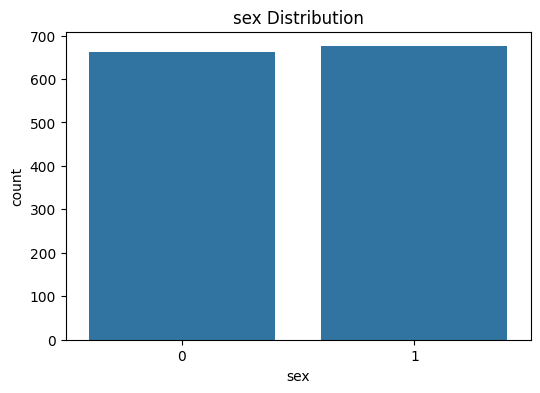

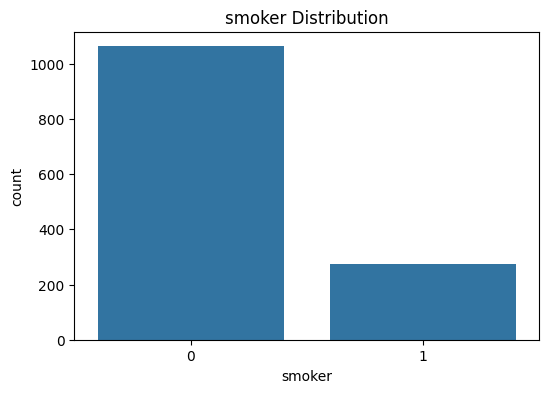

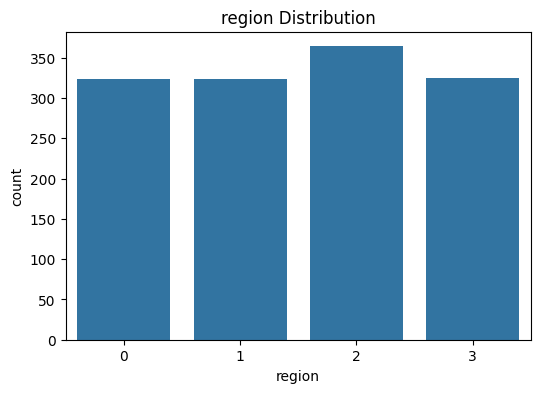

In [26]:
categorical_cols = ['sex', 'smoker', 'region']

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f"{col} Distribution")
    plt.show()

In [65]:
#insights:-The sex distribution is nearly balanced, while non-smokers are significantly more than smokers in the dataset.
#The region feature is fairly evenly distributed across all four regions, indicating no major regional imbalance.

### 9.2 Numerical Feature Distribution

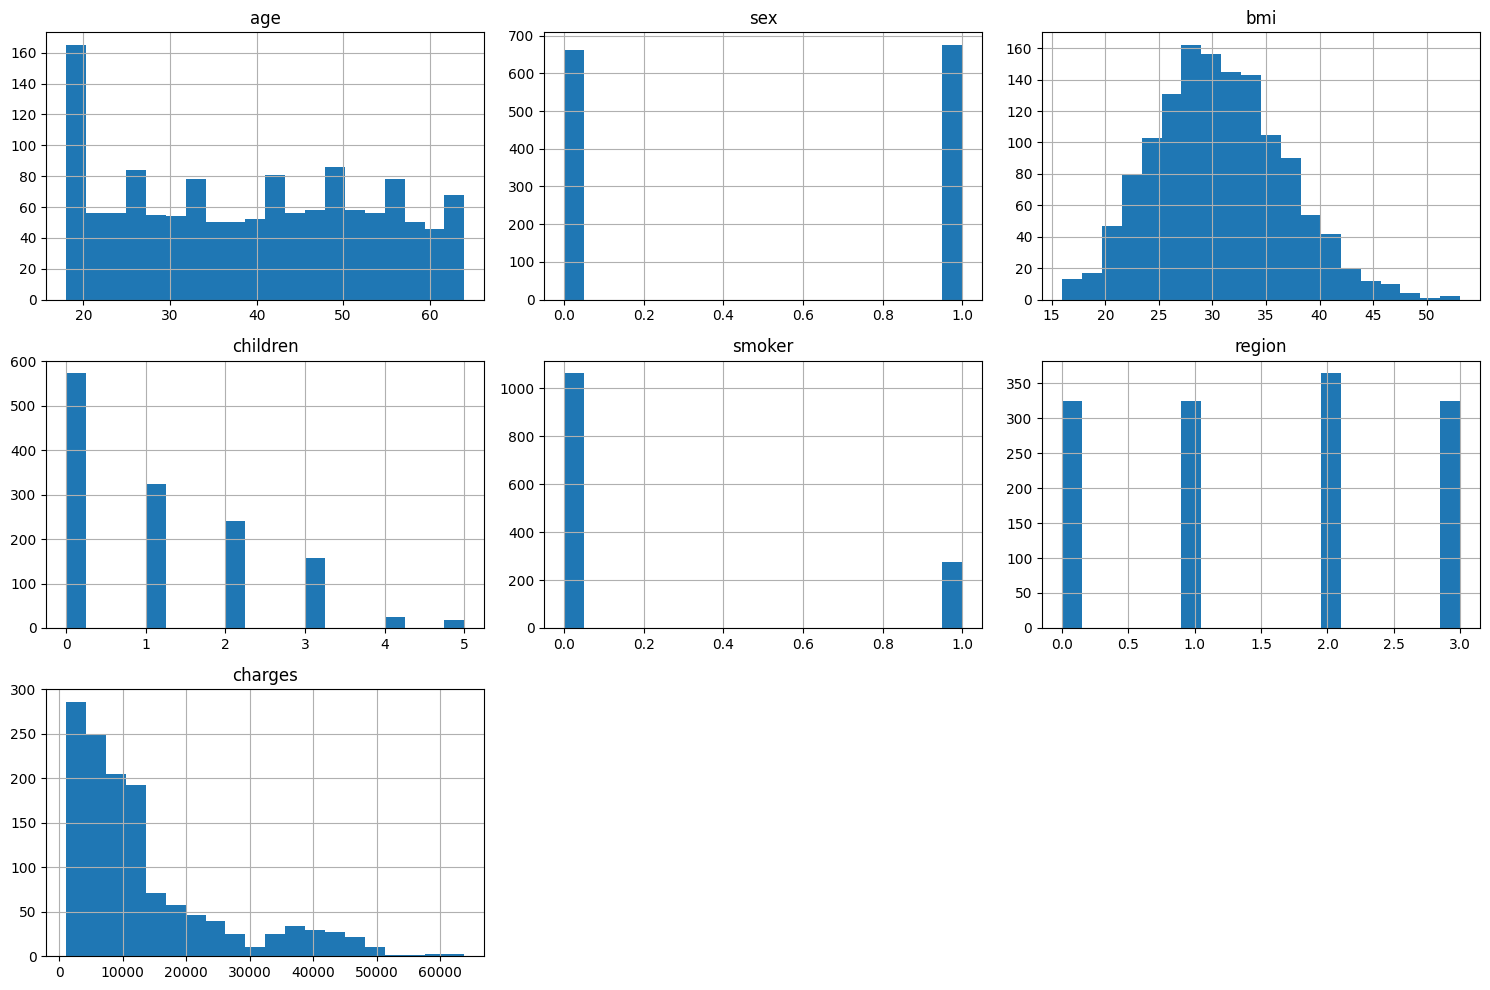

In [28]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

In [29]:
#insight:-

### 9.3 Categorical Feature Count Plots

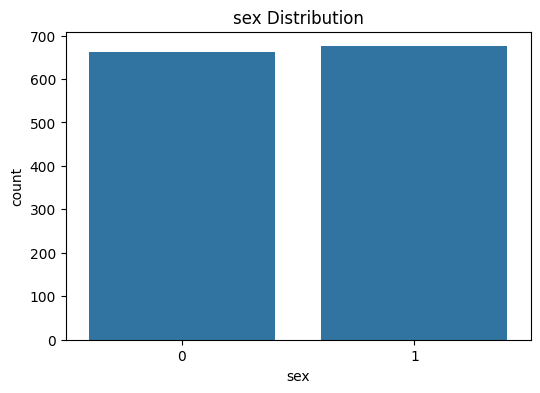

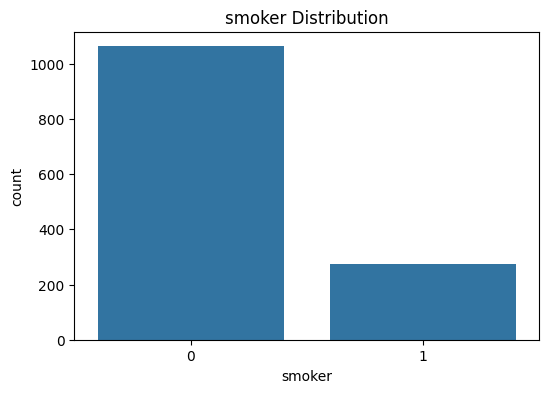

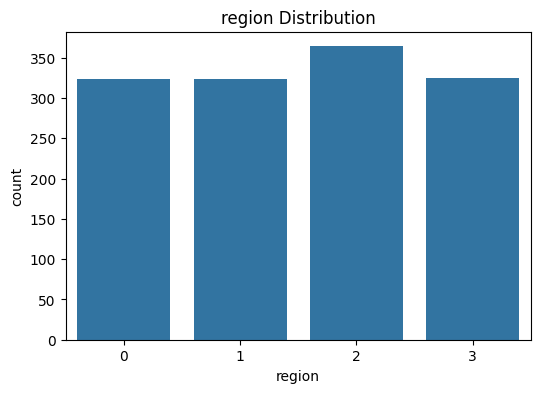

In [31]:
categorical_cols = ['sex', 'smoker', 'region']

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f"{col} Distribution")
    plt.show()

In [ ]:
#insights:-The sex distribution is nearly balanced, while non-smokers are significantly more than smokers in the dataset.
#The region feature is fairly evenly distributed across all four regions, indicating no major regional imbalance.

### 9.4 Correlation Heatmap

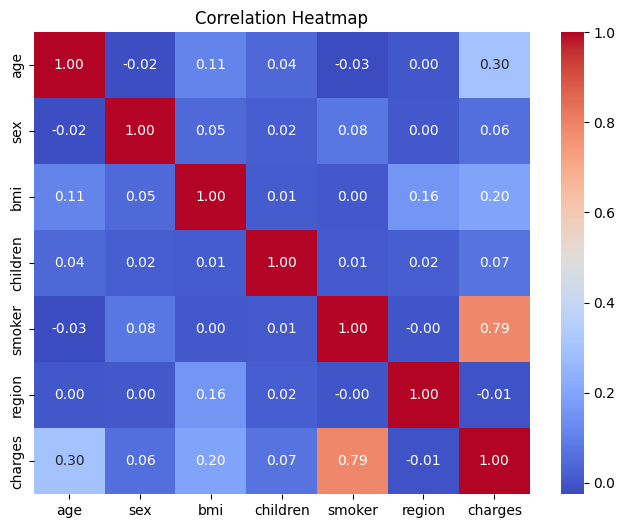

In [34]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [66]:
#insights:-The smoker feature has the strongest positive correlation with charges (0.79), indicating that smoking significantly increases insurance costs.
#Age (0.30) and BMI (0.20) show a moderate positive correlation with insurance charges, while sex, children, and region have very weak correlations with the target variable.

### .5 Outlier Detection

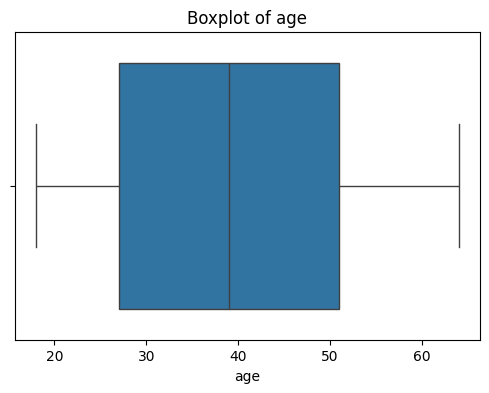

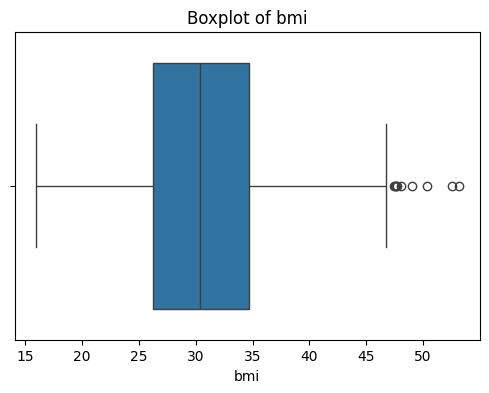

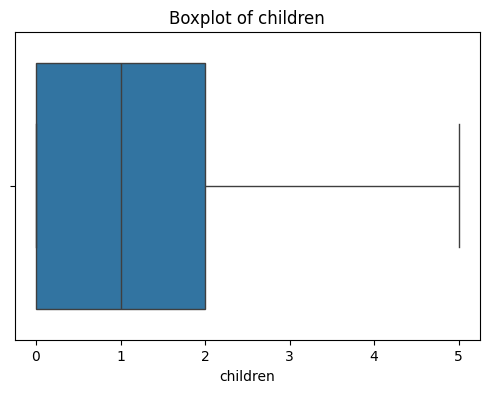

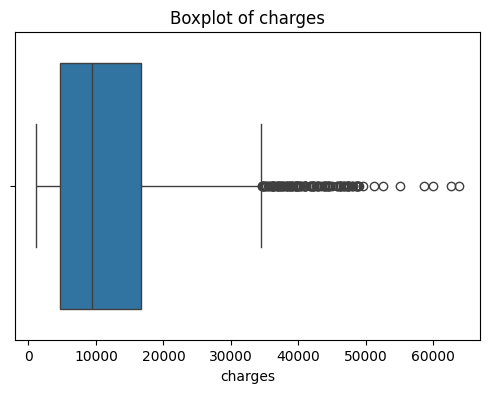

In [33]:
numerical_cols = ['age', 'bmi', 'children', 'charges']

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [35]:
#insights:-BMI and charges contain noticeable outliers, indicating some beneficiaries have unusually high BMI values and medical expenses.
#Age and children show very few or no significant outliers, suggesting these features are relatively well distributed.

### 9.6 Age vs Charges

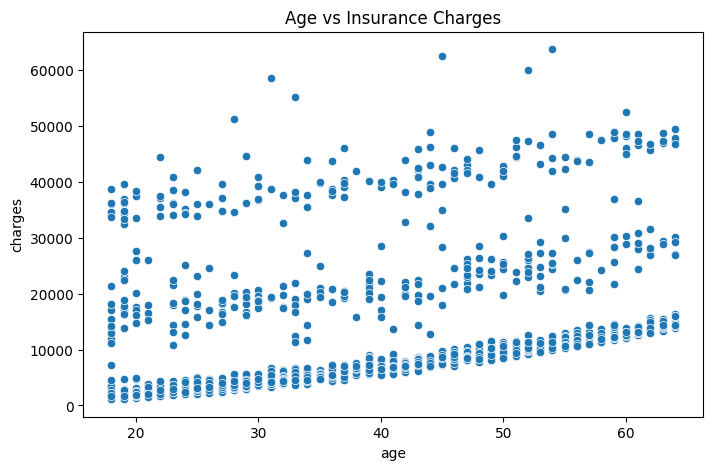

In [36]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Insurance Charges")
plt.show()

In [67]:
#insights:-Age shows a positive relationship with insurance charges, indicating that medical expenses generally increase as age increases.
#Although charges tend to rise with age, there is considerable variation, suggesting that other factors (such as smoking status and BMI) also have a significant impact on insurance costs.

### 9.7 BMI vs Charges

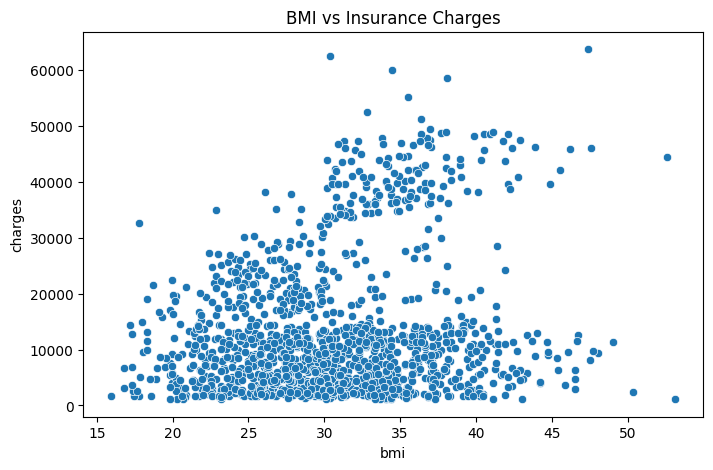

In [37]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Insurance Charges")
plt.show()

In [68]:
#insights:-BMI shows a positive relationship with insurance charges, indicating that higher BMI is generally associated with higher medical costs.
#The wide spread of data points suggests that BMI alone does not determine insurance charges; other factors, especially smoking status, also significantly influence the charges.

### 9.8 Smoker vs Charges

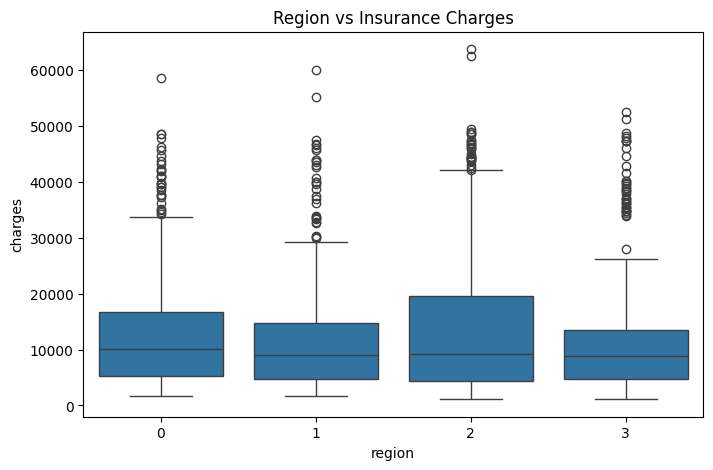

In [38]:
plt.figure(figsize=(8,5))
sns.boxplot(x='region', y='charges', data=df)
plt.title("Region vs Insurance Charges")
plt.show()

In [ ]:
#insights:-The median insurance charges are similar across all regions, indicating that region has a relatively small impact on insurance costs.
#All regions contain high-cost outliers, with Region 2 showing slightly higher variability and the highest insurance charges.

### 9.9 Region vs Charges

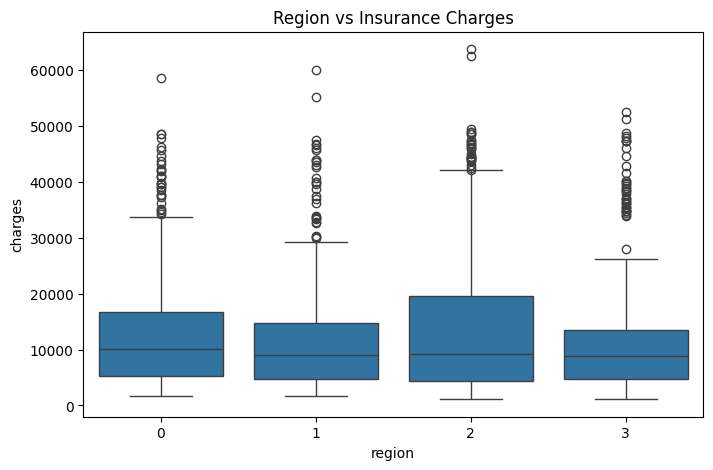

In [39]:
plt.figure(figsize=(8,5))
sns.boxplot(x='region', y='charges', data=df)
plt.title("Region vs Insurance Charges")
plt.show()

In [ ]:
#insights:-Insurance charges are fairly similar across all regions, indicating that region has a limited influence on medical insurance costs.
#Region 2 shows the highest variability and contains the highest insurance charge outliers compared to the other regions.

### 9.10 Sex vs Charges

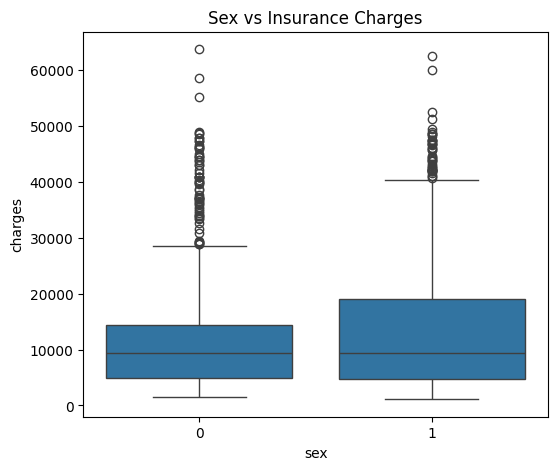

In [40]:
plt.figure(figsize=(6,5))
sns.boxplot(x='sex', y='charges', data=df)
plt.title("Sex vs Insurance Charges")
plt.show()

In [69]:
#insights:-Insurance charges are similar for both genders, indicating that gender has a relatively small impact on insurance costs.
#Both groups contain high-cost outliers, with gender 1 showing slightly higher variability and higher maximum insurance charges.

### 9.11 Children vs Charges

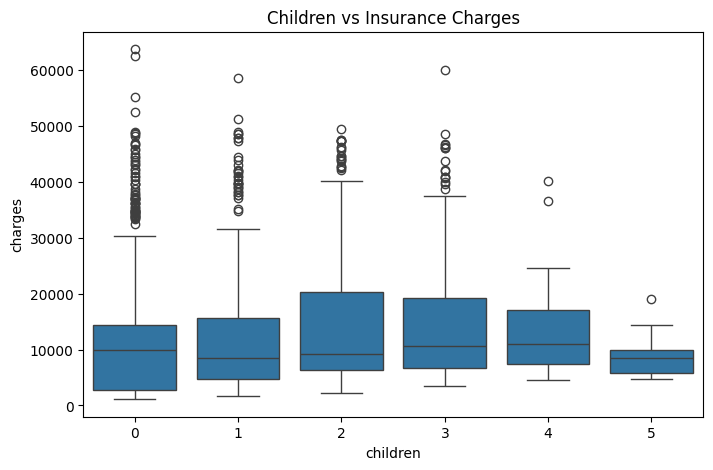

In [41]:
plt.figure(figsize=(8,5))
sns.boxplot(x='children', y='charges', data=df)
plt.title("Children vs Insurance Charges")
plt.show()

In [ ]:
#insights:-Insurance charges generally increase as the number of children increases up to 3–4, although the relationship is not very strong.
#All categories contain high-cost outliers, indicating that factors such as smoking status and BMI have a greater influence on insurance charges than the number of children.

### `9.12 Pairplot

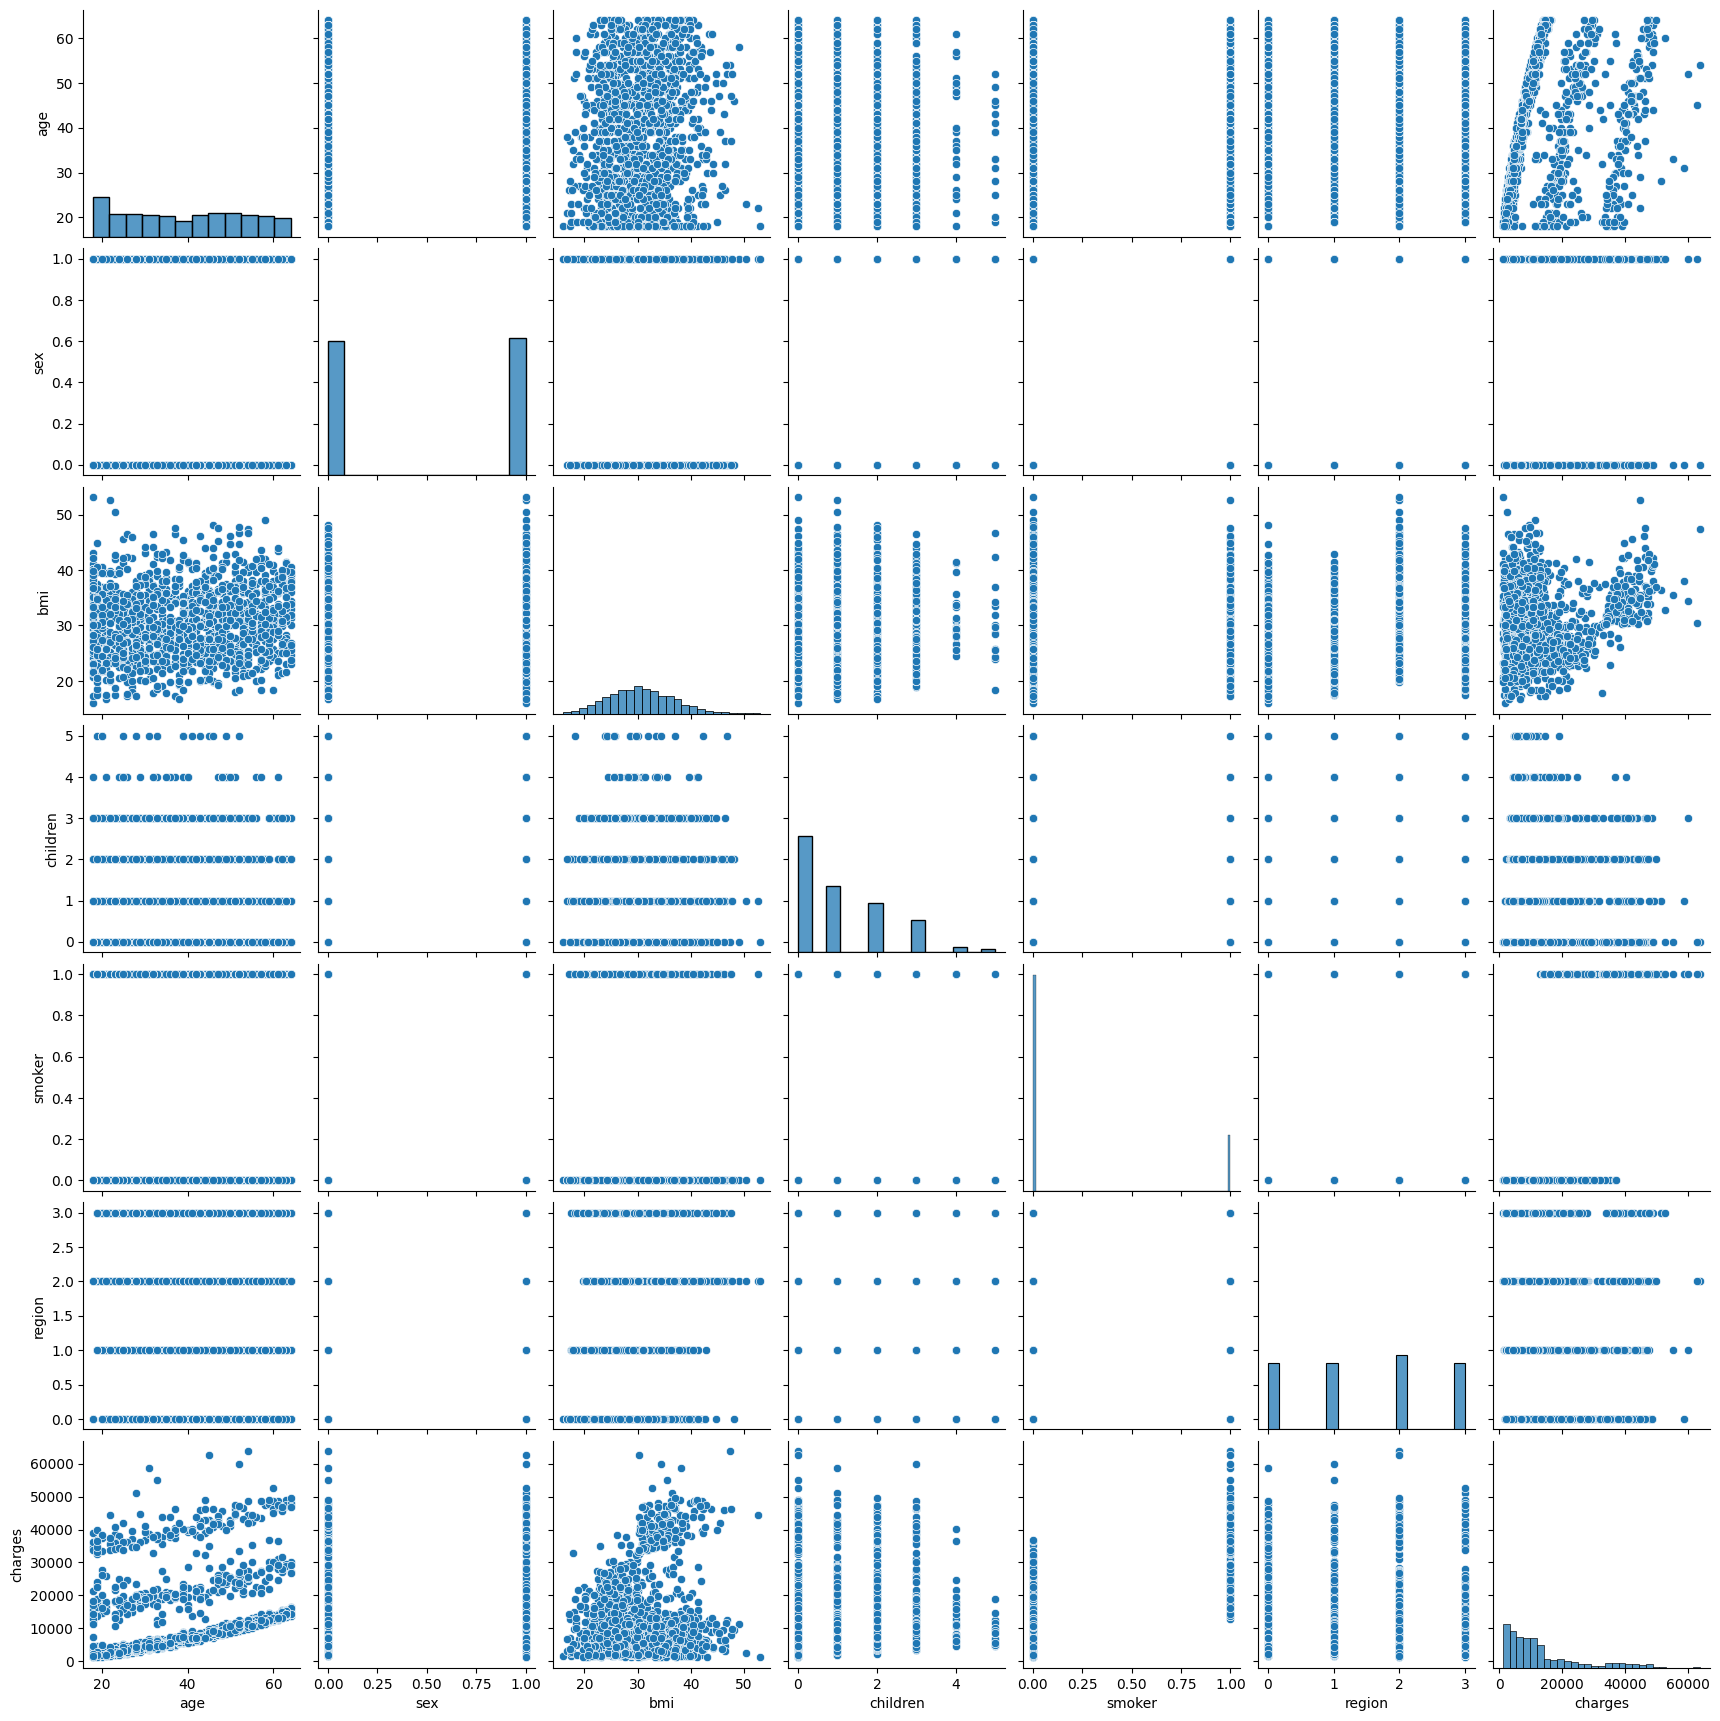

In [42]:
sns.pairplot(df)
plt.show()

In [43]:
#insighs:-The pairplot shows that age, BMI, and smoker have a noticeable relationship with insurance charges, while sex, children, and region show a weaker relationship.
#Higher insurance charges are mainly observed for older individuals, higher BMI values, and smokers, indicating these are the most important factors affecting medical costs.

## 10. Train-Test Split

### Define Features and Target

In [45]:
X = df.drop("charges", axis=1)
y = df["charges"]

###  Split the Dataset

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Check the Shape of Train and Test Data

In [47]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1069, 6)
X_test shape : (268, 6)
y_train shape: (1069,)
y_test shape : (268,)


## 11. Feature Scaling

### Initialize StandardScaler

In [48]:
scaler = StandardScaler()

### Scale the Training and Testing Data

In [49]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Verify the Scaled Data

In [50]:
X_train_scaled

array([[-1.1576804 ,  0.97140947, -0.99692768, -0.90790804, -0.50029231,
        -1.38394601],
       [-1.30061876,  0.97140947, -0.79276204,  0.7669042 , -0.50029231,
        -1.38394601],
       [ 0.91492586, -1.029432  ,  1.15466402,  0.7669042 , -0.50029231,
        -0.47798258],
       ...,
       [-1.37208794,  0.97140947, -1.4118716 , -0.07050192, -0.50029231,
         1.33394429],
       [-0.08564268, -1.029432  , -0.41997378,  1.60431032, -0.50029231,
         1.33394429],
       [-0.30005022, -1.029432  ,  0.87941237,  0.7669042 , -0.50029231,
         0.42798086]], shape=(1069, 6))

## 12. Model Building

### Linear Regression

In [51]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

### Decision Tree Regressor

In [52]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

### Random Forest Regressor

In [53]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

### Gradient Boosting Regressor

In [54]:
gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

## 13. Model Evaluation

###  Linear Regression

In [55]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE :", lr_mae)
print("MSE :", lr_mse)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

Linear Regression
MAE : 4182.3531552883
MSE : 35493102.61165055
RMSE: 5957.608799816462
R2 Score: 0.806846632262911


### Decision Tree Regressor

In [56]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Regressor")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)

Decision Tree Regressor
MAE : 2948.17890425
MSE : 40184285.07078592
RMSE: 6339.107592617901
R2 Score: 0.7813172300980598


### Random Forest Regressor

In [57]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regressor")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Regressor
MAE : 2555.9294270283576
MSE : 21420846.45966618
RMSE: 4628.2660316436195
R2 Score: 0.8834278119122363


### Gradient Boosting Regressor

In [58]:
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_mse = mean_squared_error(y_test, gb_pred)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Regressor")
print("MAE :", gb_mae)
print("MSE :", gb_mse)
print("RMSE:", gb_rmse)
print("R2 Score:", gb_r2)

Gradient Boosting Regressor
MAE : 2508.41811836199
MSE : 18170259.107231136
RMSE: 4262.658689976379
R2 Score: 0.901117499430293


## 14. Model Comparison

In [59]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor",
        "Gradient Boosting Regressor"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae,
        gb_mae
    ],
    "MSE": [
        lr_mse,
        dt_mse,
        rf_mse,
        gb_mse
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2 Score": [
        lr_r2,
        dt_r2,
        rf_r2,
        gb_r2
    ]
})

results = results.sort_values(by="R2 Score", ascending=False)
results.reset_index(drop=True, inplace=True)

results

,Model,MAE,MSE,RMSE,R2 Score
0,Gradient Boosting Regressor,2508.418118,1.817026e+07,4262.658690,0.901117
1,Random Forest Regressor,2555.929427,2.142085e+07,4628.266032,0.883428
2,Linear Regression,4182.353155,3.549310e+07,5957.608800,0.806847
3,Decision Tree Regressor,2948.178904,4.018429e+07,6339.107593,0.781317


## 15. Best Model Selection

In [62]:
best_model = pd.DataFrame({
    "Criteria": [
        "Selected Model",
        "R2 Score",
        "MAE",
        "MSE",
        "RMSE",
        "Reason for Selection",
        "Production Recommendation"
    ],
    "Value": [
        "Gradient Boosting Regressor",
        0.9011,
        2508.42,
        18170259.11,
        4262.66,
        "Highest R2 Score and lowest MAE, MSE, and RMSE",
        "Recommended for production"
    ]
})

best_model

,Criteria,Value
0,Selected Model,Gradient Boosting Regressor
1,R2 Score,0.9011
2,MAE,2508.42
3,MSE,18170259.11
4,RMSE,4262.66
5,Reason for Selection,"Highest R2 Score and lowest MAE, MSE, and RMSE"
6,Production Recommendation,Recommended for production


## 16. Challenges Faced



| **Challenge**                       | **Technique Used**                                                                                              |
| ----------------------------------- | --------------------------------------------------------------------------------------------------------------- |
| Handling categorical variables      | Applied Label Encoding to convert categorical features into numerical values.                                   |
| Duplicate records                   | Removed duplicate records to improve data quality.                                                              |
| Different feature scales            | Applied StandardScaler before training the Linear Regression model.                                             |
| Selecting the best model            | Compared multiple regression models using MAE, MSE, RMSE, and R2 Score.                                         |
| Understanding feature relationships | Performed Exploratory Data Analysis (EDA) using histograms, boxplots, scatter plots, and a correlation heatmap. |
| Improving prediction accuracy       | Evaluated different regression algorithms and selected the best-performing model based on evaluation metrics.   |




## 17. Conclusion

#This project developed a machine learning model to predict medical insurance charges based on customer information. After data preprocessing, EDA, feature scaling, model building, and evaluation, different regression models were compared using MAE, MSE, RMSE, and R2 Score.
#Among all the models, the Gradient Boosting Regressor achieved the best performance with the highest R2 Score (0.9011) and the lowest prediction errors. Therefore, it is selected as the final model for predicting insurance charges and is recommended for production use.